In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
data = np.load("field-aberrations.pkl",allow_pickle=True)
data

[(-10.0,
  [-1467.591517021019,
   120.87686352336202,
   0.07629554917464468,
   -619.9689711937071,
   0.020229857238116458,
   -5127.185683843198,
   -0.04195634006841019,
   102.32779806739141,
   0.0007946506673349705,
   2.8693548786521537,
   27.523891493397645,
   -14.7468135922629,
   0.0008135257277574167,
   0.0006908711204503305,
   -0.000199837275039223]),
 (-9.5,
  [-1171.1129286065652,
   85.2329175229315,
   0.04585315462188069,
   -482.3612286055766,
   0.018157154792026182,
   -4631.7196784965245,
   -0.03463926822809799,
   80.05315750739905,
   0.0007419754394285226,
   2.465047149022915,
   24.771632055880485,
   -13.381978255001764,
   0.0007748340226394482,
   0.0009351527103268613,
   -0.00019207398078656502]),
 (-9.0,
  [-924.2532689092676,
   58.31630091718816,
   0.03023213698369907,
   -373.4777456984798,
   0.017326938224179418,
   -4161.135857933944,
   -0.027744310478187734,
   60.391842321493414,
   0.0006756996679584918,
   2.0972831926920805,
   22.158

In [15]:
z = np.asarray([x[0] for x in data] )
astigmatism = np.asarray([np.hypot(x[1][4],x[1][5]) for x in data] )
coma = np.asarray([x[1][7] for x in data] )
spherical = np.asarray([x[1][10] for x in data] )

In [16]:
p_astigmatism = np.polyfit(z,astigmatism,2)
p_coma = np.polyfit(z,coma,3)
p_spherical = np.polyfit(z,spherical,2)

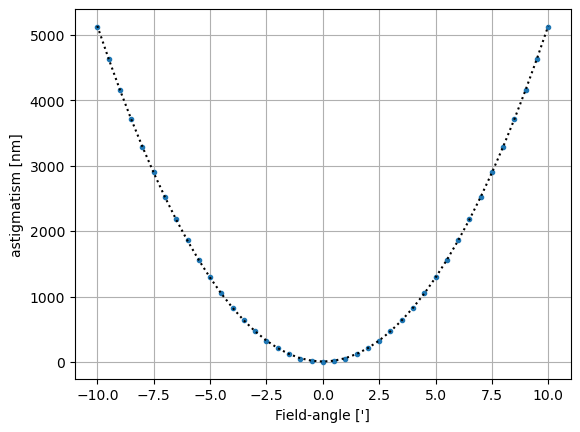

In [17]:
fig,ax = plt.subplots()
ax.plot(z,astigmatism,'.')
ax.plot(z,np.polyval(p_astigmatism,z),'k:')
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("astigmatism [nm]")
ax.grid()

In [18]:
p_coma,p_spherical

(array([-1.89492033e-01,  5.14945671e-04,  8.65529272e+00, -8.69323034e-03]),
 array([ 0.27438788, -0.00091882, -0.09196654]))

In [19]:
p_coma,p_spherical

(array([-1.89492033e-01,  5.14945671e-04,  8.65529272e+00, -8.69323034e-03]),
 array([ 0.27438788, -0.00091882, -0.09196654]))

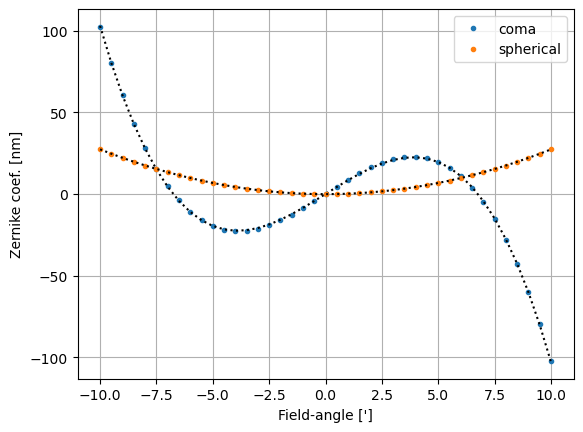

In [20]:
fig,ax = plt.subplots()
ax.plot(z,coma,'.',label="coma")
ax.plot(z,np.polyval(p_coma,z),'k:')
ax.plot(z,spherical,'.',label="spherical")
ax.plot(z,np.polyval(p_spherical,z),'k:')
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("Zernike coef. [nm]")
ax.grid()
ax.legend()

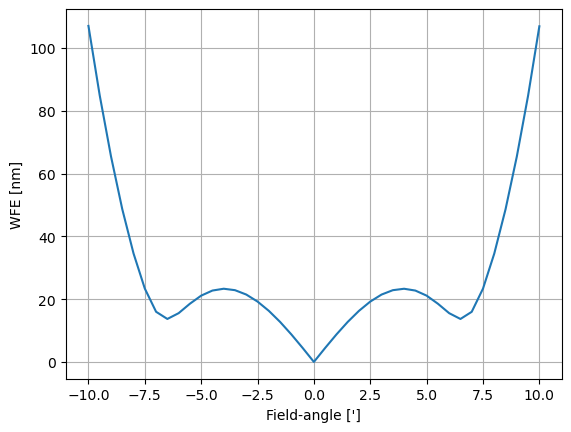

In [57]:
wfe = np.asarray([np.sqrt(np.sum(np.asarray(x[1][7:])**2)) for x in data] )
fig,ax = plt.subplots()
ax.plot(z,wfe)
#ax.set_xticks(np.arange(-10,11))
ax.set_xlabel("Field-angle [']")
ax.set_ylabel("WFE [nm]")
ax.grid()